In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import seaborn as sns

In [2]:
data = os.listdir("testing\\traning")
classes = {"Yes":1, "no cancer":0}

In [3]:
data

['blood cancer',
 'bone cancer',
 'lung cancer',
 'no cancer',
 'prostate cancer',
 'skin cancer',
 'yes']

In [4]:
classes

{'Yes': 1, 'no cancer': 0}

In [5]:
x=[]
y=[]
for cls in classes:
    path = r"testing/traning/"+cls
    for j in os.listdir(path):
        img = cv2.imread(path+"/"+j, 0)  #0 -> img should be in gray scale
        img = cv2.resize(img,(200, 200))
        x.append(img)
        y.append(classes[cls])

In [6]:
np.unique(y)

array([0, 1])

In [7]:
x = np.array(x)
y = np.array(y)
#converting x and y into numpy arrays

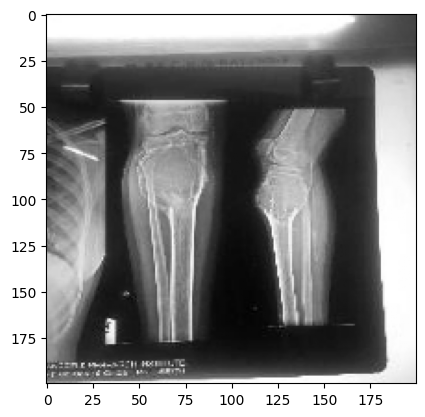

In [8]:
plt.imshow(x[0], cmap="gray") #shows first image from dataset
plt.show()

In [9]:
pd.Series(y).value_counts()
#converting y input into a pandas series

1    3728
0     885
Name: count, dtype: int64

In [10]:
x.shape

(4613, 200, 200)

In [11]:
updated_x = x.reshape(len(x), -1)
updated_x.shape

(4613, 40000)

In [12]:
updated_x[0] #accessing first element of a variable

array([241, 244, 248, ..., 227, 227, 227], shape=(40000,), dtype=uint8)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(updated_x, y, test_size = 0.2, random_state = 10)
# 10-> guarantees the split will be the same every time the code is run

In [15]:
x_train.shape, y_train.shape #returns dimensions
# rows and columns, rows only 

((3690, 40000), (3690,))

In [16]:
x_test.shape, y_test.shape
# 224(total no. of rows), 40000(total no. of columns)
#testing set consists of 224 samples each described by 40000 features

((923, 40000), (923,))

In [17]:
x_train = x_train/255
x_test = x_test/255 

In [18]:
x_train

array([[0.09411765, 0.12941176, 0.1372549 , ..., 0.76078431, 0.54901961,
        0.55294118],
       [0.01176471, 0.01176471, 0.01176471, ..., 0.04705882, 0.04313725,
        0.03921569],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.8627451 , 0.8745098 , 0.8745098 , ..., 0.88627451, 0.86666667,
        0.87058824],
       [0.83921569, 0.83529412, 0.83529412, ..., 0.78039216, 0.77647059,
        0.78431373],
       [0.49803922, 0.50196078, 0.50588235, ..., 0.47058824, 0.46666667,
        0.46666667]], shape=(3690, 40000))

In [19]:
x_test

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.87843137, 0.87843137, 0.87843137, ..., 0.8627451 , 0.8627451 ,
        0.8627451 ],
       ...,
       [0.89019608, 0.89019608, 0.89019608, ..., 0.86666667, 0.89803922,
        0.89803922],
       [0.        , 0.        , 0.        , ..., 0.15686275, 0.11372549,
        0.1254902 ],
       [0.94901961, 0.94509804, 0.95294118, ..., 0.90196078, 0.90196078,
        0.89803922]], shape=(923, 40000))

In [20]:
from sklearn.linear_model import LogisticRegression  # used for binary and multiclass classification
from sklearn.ensemble import RandomForestClassifier # builds multiple decision trees during training and merges thir predictions
from sklearn.tree import DecisionTreeClassifier # A non-linear model that partitions the data space into a set of rectangles, making decisions based on features
from sklearn.svm import SVC  #support vector classifier -> separates classes in a high-dimensional spaces
from sklearn.metrics import accuracy_score, confusion_matrix

In [21]:
model_name = {
    "logistic" : LogisticRegression(),
    "Random" : RandomForestClassifier(),
    "Decision Tree" : DecisionTreeClassifier(),
    "SVM": SVC()
}

C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic = 0.9404117009750813


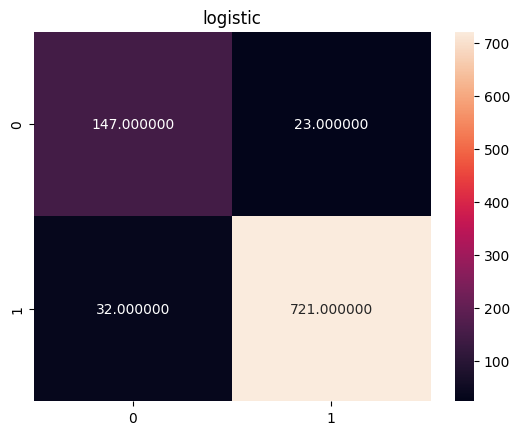

Random = 0.9674972914409534


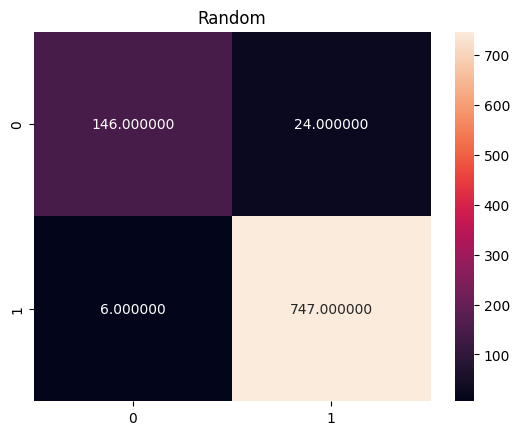

Decision Tree = 0.9241603466955579


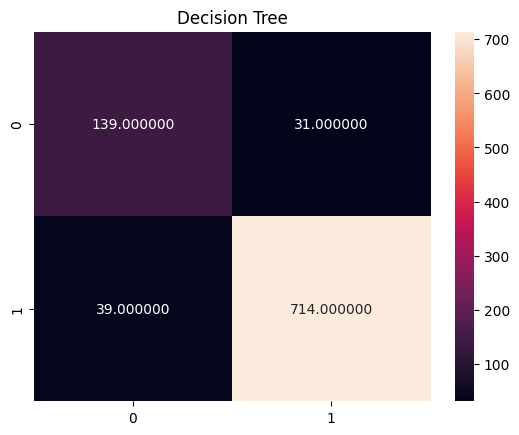

SVM = 0.942578548212351


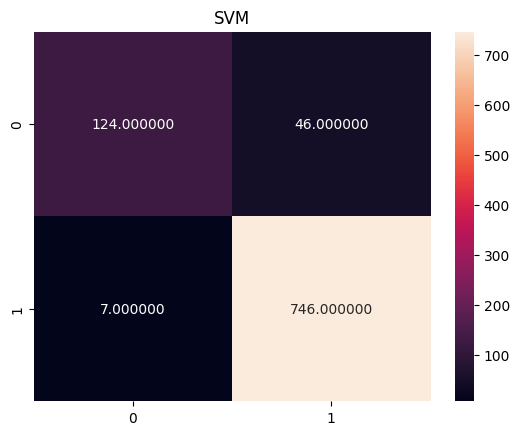

In [22]:
for model_names, model in model_name.items():
    model.fit(x_train, y_train)  #model training & prediction
    y_pred = model.predict(x_test)
    print(f"{model_names} = {accuracy_score(y_test, y_pred)}")  # evaluation & output
    confusion_mat = confusion_matrix(y_test, y_pred)  # confusion matrix visualization
    sns.heatmap(confusion_mat, annot = True, fmt = "2f") # 2 decimal places  # calls the heatmap function from seaborn library
    plt.title(f"{model_names}")
    plt.show()

In [23]:
random_forest_model = RandomForestClassifier()

In [24]:
random_forest_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
print(f"Training Accuracy {random_forest_model.score(x_train, y_train)}")
print(f"Testing Accuracy {random_forest_model.score(x_test, y_test)}")

Training Accuracy 1.0
Testing Accuracy 0.9664138678223185


In [26]:
import joblib

In [27]:
joblib.dump(random_forest_model, "cancer_detection.joblib")

['cancer_detection.joblib']

In [28]:
desc = {1 : "positive_cancer", 0 : "no cancer"}